<a href="https://colab.research.google.com/github/nilesh426/CSL701-42_Machine-Learning-Lab/blob/main/Experiments/ML_EXP7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Nilesh Ashok Sawant

Batch : CE3


Roll Number : CE42



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Upload CSV file
from google.colab import files

uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

# Display dataset information
print("Selected File:", file_name)
print("Dataset Shape:", df.shape)

# Display first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

Saving data (1).csv to data (1) (1).csv
Selected File: data (1) (1).csv
Dataset Shape: (569, 33)

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030          

After running the cell above and uploading your dataset, you will see the filename printed. You will need to replace `'your_actual_filename.csv'` in the next cell with the name of the file you uploaded.

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst

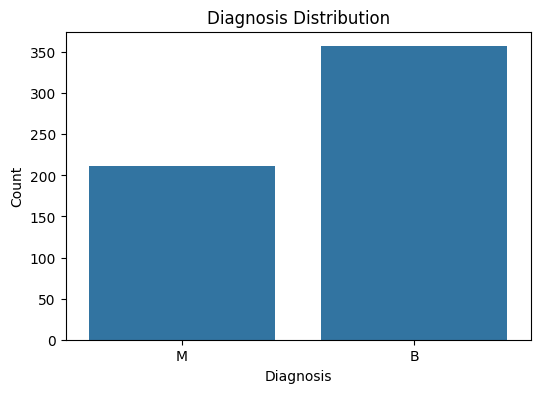

In [ ]:
# Task 2: Explore the Dataset

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Dataset information
print("\nDataset Information:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Target class distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# Plot diagnosis distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Task 3: Data Cleaning and Feature/Target Selection

# Drop metadata columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis into numerical values
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Display shapes
print("Feature Matrix X shape:", X.shape)
print("Target Vector y shape:", y.shape)

# Display feature names
print("\nFeature Names:")
print(X.columns.tolist())

# Display first 5 rows
print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

Feature Matrix X shape: (569, 30)
Target Vector y shape: (569,)

Feature Names:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

X:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0

# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Task 4: Standardize Features

# Create StandardScaler object
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Display first 5 rows
print("Standardized Features:")
print(X_scaled.head())

# Check mean and standard deviation
print("\nMean of standardized features:")
print(X_scaled.mean().round(4))

print("\nStandard deviation of standardized features:")
print(X_scaled.std().round(4))

Standardized Features:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimete

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Task 5: Implement PCA

# Create PCA with 2 components
pca = PCA(n_components=2)

# Transform the standardized data
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame containing PC1 and PC2
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add diagnosis
pca_df["diagnosis"] = y.values

# Display first 5 rows
print(pca_df.head())

# Display shape
print("\nPCA Data Shape:", pca_df.shape)

        PC1        PC2  diagnosis
0  9.192837   1.948583          1
1  2.387802  -3.768172          1
2  5.733896  -1.075174          1
3  7.122953  10.275589          1
4  3.935302  -1.948072          1

PCA Data Shape: (569, 3)


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
# Task 6: Analyze Explained Variance Ratio

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# PC1 variance
pc1_variance = explained_variance[0]

# PC2 variance
pc2_variance = explained_variance[1]

# Cumulative variance
cumulative_variance = explained_variance.sum()

print("Variance explained by PC1:", pc1_variance)
print("Variance explained by PC2:", pc2_variance)
print("Cumulative variance retained:", cumulative_variance)

# Print percentages
print("\nPC1 Variance Explained: {:.2f}%".format(pc1_variance * 100))
print("PC2 Variance Explained: {:.2f}%".format(pc2_variance * 100))
print("Cumulative Variance Retained: {:.2f}%".format(cumulative_variance * 100))

Variance explained by PC1: 0.44272025607526366
Variance explained by PC2: 0.18971182044033078
Cumulative variance retained: 0.6324320765155944

PC1 Variance Explained: 44.27%
PC2 Variance Explained: 18.97%
Cumulative Variance Retained: 63.24%


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

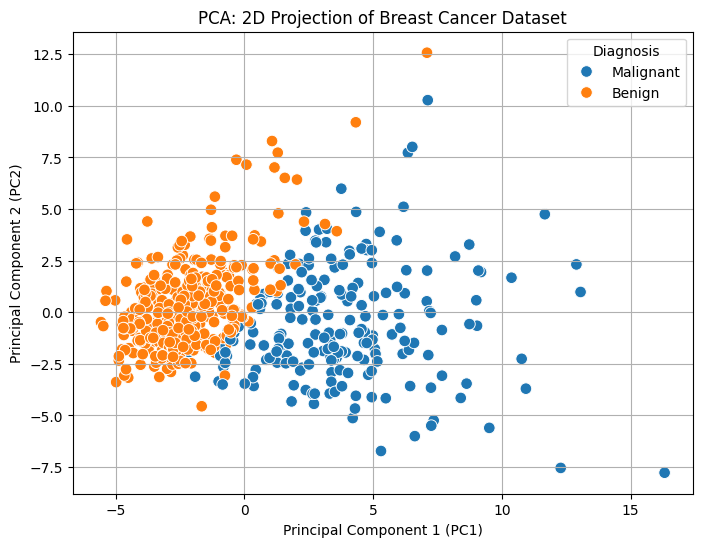

In [ ]:
# Create readable diagnosis labels
pca_plot = pca_df.copy()

pca_plot["Diagnosis"] = pca_plot["diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    s=70
)

plt.title("PCA: 2D Projection of Breast Cancer Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Task 8: Logistic Regression using 30 Features

# Split the standardized 30-feature dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_model_raw = LogisticRegression(max_iter=1000)

# Train model
logistic_model_raw.fit(X_train, y_train)

# Make predictions
y_pred_raw = logistic_model_raw.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression using 30 Features")
print("--------------------------------------")
print("Accuracy:", accuracy_raw)
print("Accuracy (%): {:.2f}%".format(accuracy_raw * 100))

Logistic Regression using 30 Features
--------------------------------------
Accuracy: 0.9649122807017544
Accuracy (%): 96.49%


# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Task 9: Logistic Regression using 2 PCA Features

# Separate PCA features
X_pca_features = pca_df[["PC1", "PC2"]]

# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_model_pca = LogisticRegression(max_iter=1000)

# Train model
logistic_model_pca.fit(X_train_pca, y_train_pca)

# Make predictions
y_pred_pca = logistic_model_pca.predict(X_test_pca)

# Calculate accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("Logistic Regression using 2 PCA Features")
print("-----------------------------------------")
print("Accuracy:", accuracy_pca)
print("Accuracy (%): {:.2f}%".format(accuracy_pca * 100))

Logistic Regression using 2 PCA Features
-----------------------------------------
Accuracy: 0.9385964912280702
Accuracy (%): 93.86%


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
# Task 10: Compare Classifier Performance

# =========================================================
# 1. Accuracy
# =========================================================

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

print("\nAccuracy Scores")
print("-" * 60)

print("30 Features Model : {:.2f}%".format(accuracy_raw * 100))
print("2 PCA Features    : {:.2f}%".format(accuracy_pca * 100))


# =========================================================
# 2. Confusion Matrix - 30 Features
# =========================================================

cm_raw = confusion_matrix(y_test, y_pred_raw)

print("\nConfusion Matrix - 30 Features")
print(cm_raw)


# =========================================================
# 3. Confusion Matrix - PCA
# =========================================================

cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

print("\nConfusion Matrix - 2 PCA Features")
print(cm_pca)


# =========================================================
# 4. Classification Report - 30 Features
# =========================================================

print("\nClassification Report - 30 Features")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred_raw,
        target_names=["Benign", "Malignant"]
    )
)


# =========================================================
# 5. Classification Report - PCA
# =========================================================

print("\nClassification Report - 2 PCA Features")
print("-" * 60)

print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"]
    )
)

MODEL PERFORMANCE COMPARISON

Accuracy Scores
------------------------------------------------------------
30 Features Model : 96.49%
2 PCA Features    : 93.86%

Confusion Matrix - 30 Features
[[71  1]
 [ 3 39]]

Confusion Matrix - 2 PCA Features
[[71  1]
 [ 6 36]]

Classification Report - 30 Features
------------------------------------------------------------
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report - 2 PCA Features
------------------------------------------------------------
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94 

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.